# Прогнозирование кредитного дефолта
## Полный ML Pipeline: EDA → Preprocessing → Modelling → Custom Logistic Regression

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
RANDOM_STATE = 42
print('Импорты выполнены успешно')

Импорты выполнены успешно


## 1. EDA — Разведочный анализ данных

In [2]:
train = pd.read_csv('course_project_train.csv')
test  = pd.read_csv('course_project_test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (7500, 17)
Test shape:  (2500, 16)


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


In [3]:
print('=== Типы данных и пропуски ===')
info = pd.DataFrame({
    'dtype': train.dtypes,
    'nulls': train.isnull().sum(),
    'null_%': (train.isnull().sum() / len(train) * 100).round(2)
})
print(info)
print('\n=== Статистика числовых признаков ===')
train.describe()

=== Типы данных и пропуски ===
                                dtype  nulls  null_%
Home Ownership                 object      0    0.00
Annual Income                 float64   1557   20.76
Years in current job           object    371    4.95
Tax Liens                     float64      0    0.00
Number of Open Accounts       float64      0    0.00
Years of Credit History       float64      0    0.00
Maximum Open Credit           float64      0    0.00
Number of Credit Problems     float64      0    0.00
Months since last delinquent  float64   4081   54.41
Bankruptcies                  float64     14    0.19
Purpose                        object      0    0.00
Term                           object      0    0.00
Current Loan Amount           float64      0    0.00
Current Credit Balance        float64      0    0.00
Monthly Debt                  float64      0    0.00
Credit Score                  float64   1557   20.76
Credit Default                  int64      0    0.00

=== Статистика

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
count,5.943000e+03,7500.000000,7500.000000,7500.000000,7.500000e+03,7500.000000,3419.000000,7486.000000,7.500000e+03,7.500000e+03,7500.000000,5943.000000,7500.000000
mean,1.366392e+06,0.030133,11.130933,18.317467,9.451537e+05,0.170000,34.692600,0.117152,1.187318e+07,2.898332e+05,18314.454133,1151.087498,0.281733
std,8.453392e+05,0.271604,4.908924,7.041946,1.602622e+07,0.498598,21.688806,0.347192,3.192612e+07,3.178714e+05,11926.764673,1604.451418,0.449874
min,1.645970e+05,0.000000,2.000000,4.000000,0.000000e+00,0.000000,0.000000,0.000000,1.124200e+04,0.000000e+00,0.000000,585.000000,0.000000
25%,8.443410e+05,0.000000,8.000000,13.500000,2.792295e+05,0.000000,16.000000,0.000000,1.801690e+05,1.142565e+05,10067.500000,711.000000,0.000000
50%,1.168386e+06,0.000000,10.000000,17.000000,4.781590e+05,0.000000,32.000000,0.000000,3.095730e+05,2.093230e+05,16076.500000,731.000000,0.000000
75%,1.640137e+06,0.000000,14.000000,21.800000,7.935015e+05,0.000000,50.000000,0.000000,5.198820e+05,3.604062e+05,23818.000000,743.000000,1.000000
max,1.014934e+07,7.000000,43.000000,57.700000,1.304726e+09,7.000000,118.000000,4.000000,1.000000e+08,6.506797e+06,136679.000000,7510.000000,1.000000


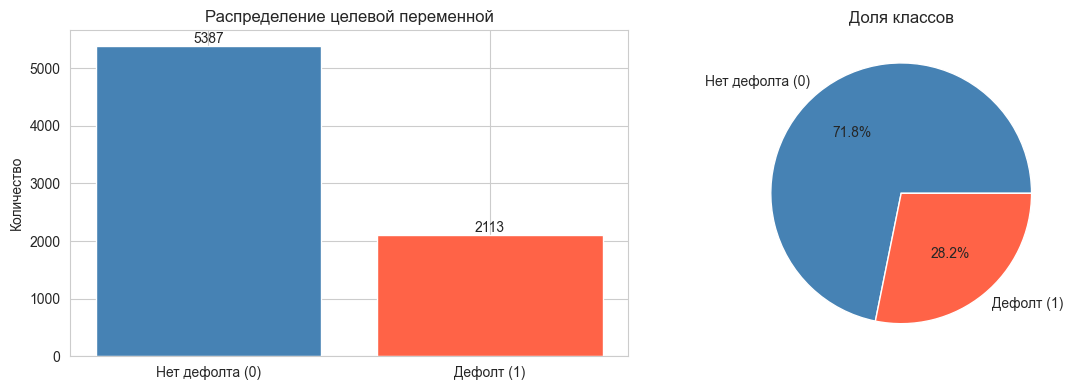

Дисбаланс классов: 5387 / 2113 = 2.55:1


In [4]:
# Распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train['Credit Default'].value_counts()
axes[0].bar(['Нет дефолта (0)', 'Дефолт (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Распределение целевой переменной')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

axes[1].pie(counts.values, labels=['Нет дефолта (0)', 'Дефолт (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.show()
print(f'Дисбаланс классов: {counts[0]} / {counts[1]} = {counts[0]/counts[1]:.2f}:1')

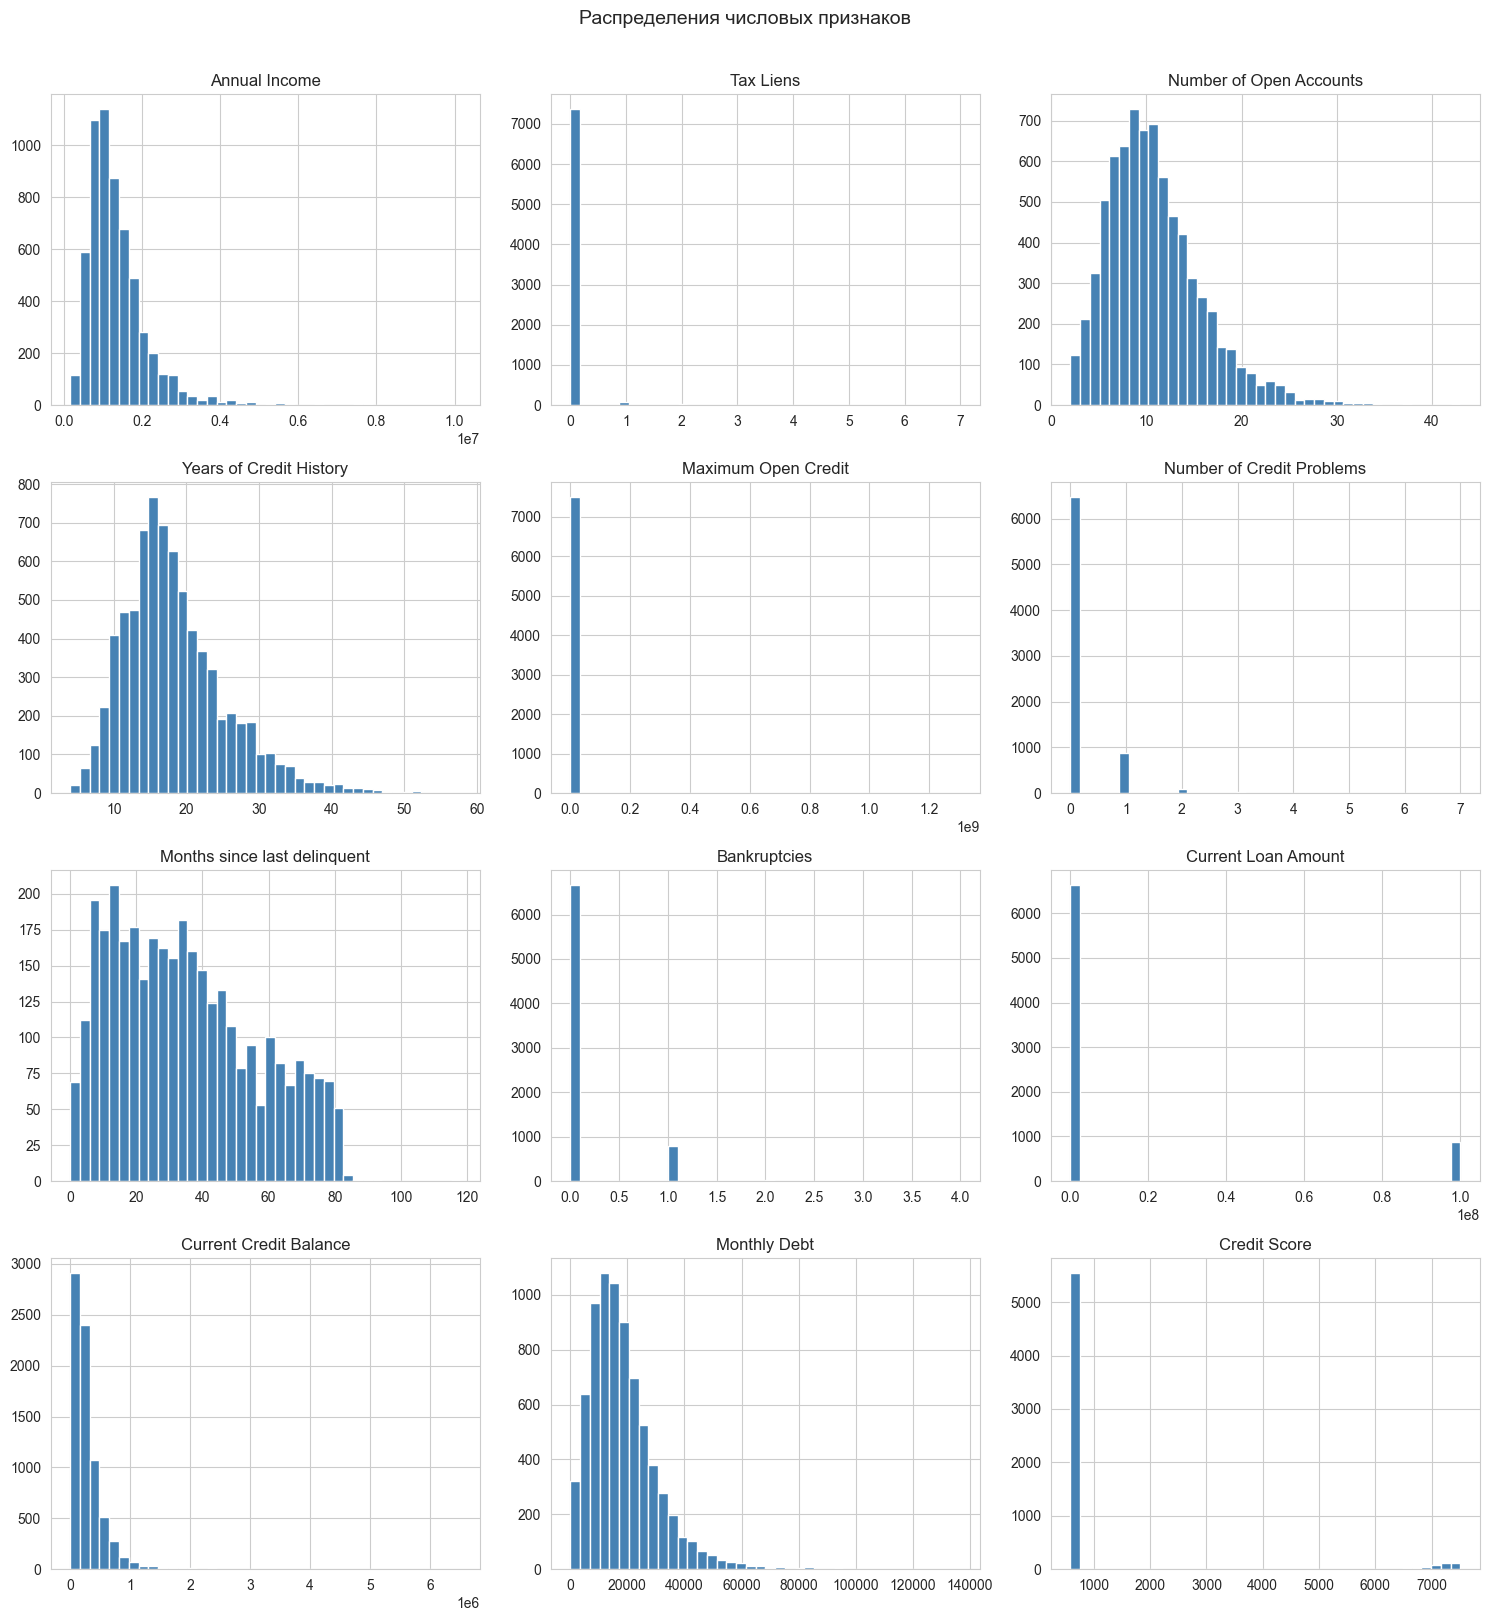

In [5]:
# Распределение числовых признаков
num_cols = train.select_dtypes(include=np.number).columns.drop('Credit Default')

ncols = 3
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    train[col].hist(ax=axes[i], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения числовых признаков', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


Категориальные признаки: ['Home Ownership', 'Years in current job', 'Purpose', 'Term']


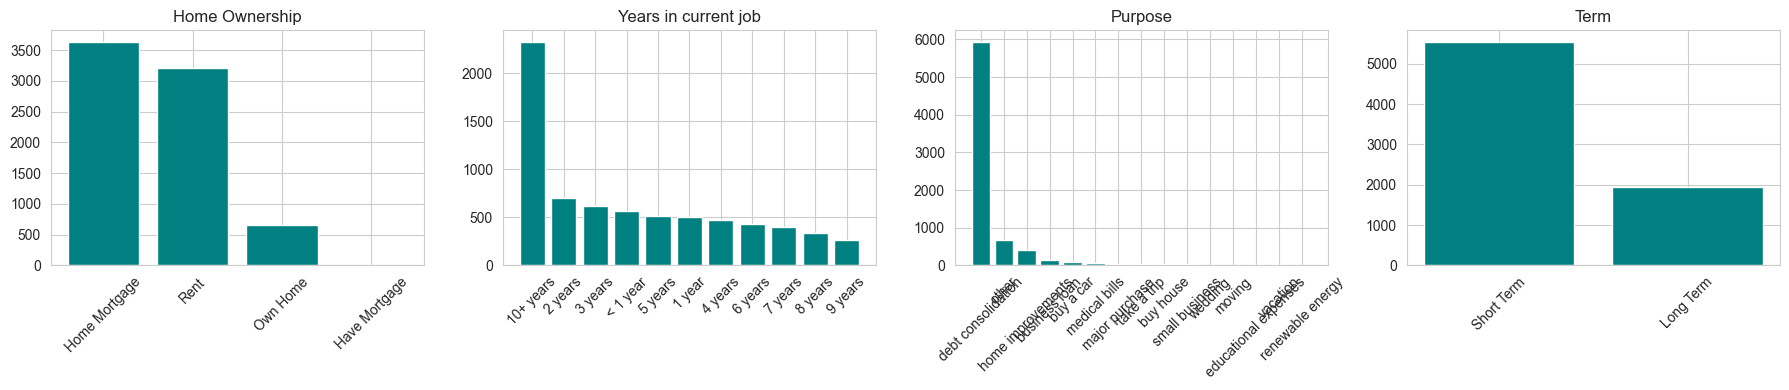

In [6]:
# Категориальные признаки
cat_cols = train.select_dtypes(include='object').columns
print('Категориальные признаки:', list(cat_cols))

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for i, col in enumerate(cat_cols):
    vc = train[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='teal')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

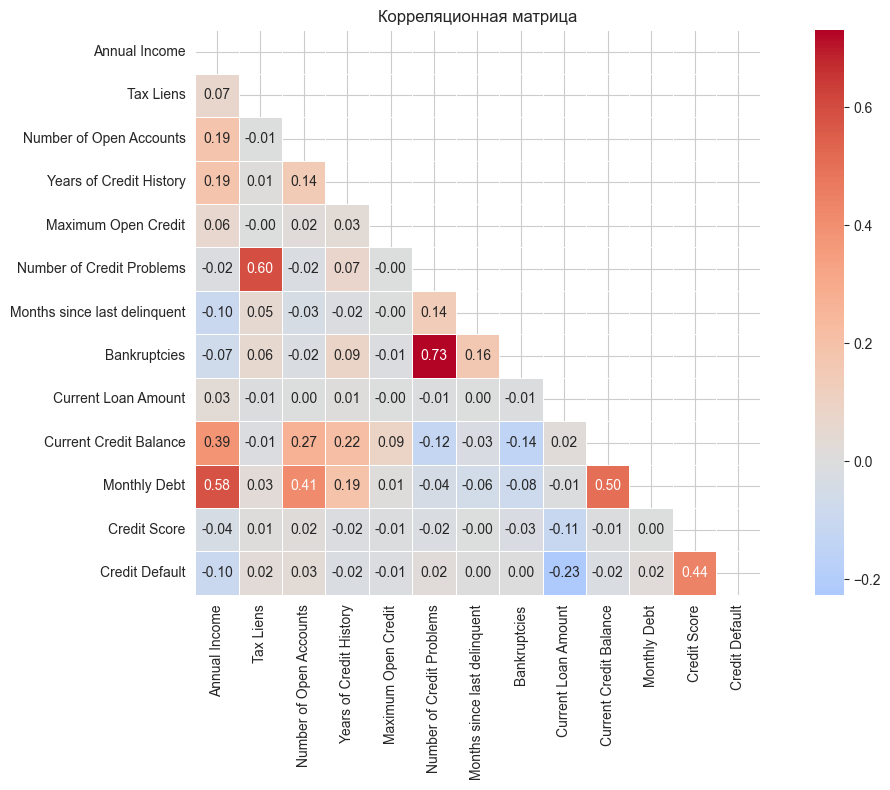

In [7]:
# Корреляционная матрица
plt.figure(figsize=(12, 8))
corr = train[num_cols.tolist() + ['Credit Default']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

In [8]:
# Проверка выбросов — Current Loan Amount
print('Уникальные значения Current Loan Amount (топ-5 наибольших):')
print(train['Current Loan Amount'].nlargest(10).unique())
print(f"\nЗначения = 99999999: {(train['Current Loan Amount'] == 99999999).sum()}")

Уникальные значения Current Loan Amount (топ-5 наибольших):
[99999999.]

Значения = 99999999: 870


## 2. Preprocessing — Предобработка данных

In [9]:
def preprocess(df, is_train=True, medians=None, modes=None):
    df = df.copy()
    
    # --- 1. Выбросы: Current Loan Amount (sentinel value 99999999)
    df['Current Loan Amount'] = df['Current Loan Amount'].replace(99999999, np.nan)
    
    # --- 2. Years in current job → числовой
    years_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8, '9 years': 9, '10+ years': 11
    }
    df['Years in current job'] = df['Years in current job'].map(years_map)
    
    # --- 3. Пропуски: числовые → медиана по train
    num_cols_fill = [
        'Annual Income', 'Years in current job', 'Months since last delinquent',
        'Current Loan Amount', 'Credit Score'
    ]
    if is_train:
        medians = {}
        for col in num_cols_fill:
            medians[col] = df[col].median()
    for col in num_cols_fill:
        df[col] = df[col].fillna(medians[col])
    
    # Bankruptcies, Tax Liens — пропуски как 0
    df['Bankruptcies'] = df['Bankruptcies'].fillna(0)
    df['Tax Liens']    = df['Tax Liens'].fillna(0)
    
    # --- 4. Категориальные: One-Hot / Binary
    # Term
    df['Term_Long'] = (df['Term'] == 'Long Term').astype(int)
    df.drop('Term', axis=1, inplace=True)
    
    # Home Ownership
    if is_train:
        modes = {'Home Ownership': df['Home Ownership'].mode()[0],
                 'Purpose': df['Purpose'].mode()[0]}
    df['Home Ownership'] = df['Home Ownership'].fillna(modes['Home Ownership'])
    df['Purpose']        = df['Purpose'].fillna(modes['Purpose'])
    
    df = pd.get_dummies(df, columns=['Home Ownership', 'Purpose'], drop_first=True)
    
    return df, medians, modes

train_proc, medians, modes = preprocess(train, is_train=True)
test_proc, _, _            = preprocess(test,  is_train=False, medians=medians, modes=modes)

# Выравниваем колонки test по train (на случай разных категорий)
TARGET = 'Credit Default'
feature_cols = [c for c in train_proc.columns if c != TARGET]
test_proc = test_proc.reindex(columns=feature_cols, fill_value=0)

print('Train после обработки:', train_proc.shape)
print('Test  после обработки:', test_proc.shape)
print('Пропуски в train:', train_proc.isnull().sum().sum())
print('Пропуски в test: ', test_proc.isnull().sum().sum())

Train после обработки: (7500, 32)
Test  после обработки: (2500, 31)
Пропуски в train: 0
Пропуски в test:  0


## 3. Feature Engineering — Генерация признаков

In [10]:
def add_features(df):
    df = df.copy()
    # Долговая нагрузка
    df['Debt_to_Income'] = df['Monthly Debt'] * 12 / (df['Annual Income'] + 1)
    # Использование кредита
    df['Credit_Utilization'] = df['Current Credit Balance'] / (df['Maximum Open Credit'] + 1)
    # Кредитная нагрузка на счёт
    df['Debt_per_Account'] = df['Monthly Debt'] / (df['Number of Open Accounts'] + 1)
    # Флаг наличия просрочки
    df['Has_Delinquent'] = (df['Months since last delinquent'] < 999).astype(int)
    return df

train_fe = add_features(train_proc)
test_fe  = add_features(test_proc)

print('Новые признаки добавлены. Итоговых признаков:', train_fe.shape[1] - 1)

Новые признаки добавлены. Итоговых признаков: 35


## 4. Моделирование

In [11]:
X = train_fe.drop(TARGET, axis=1)
y = train_fe[TARGET]
X_test_final = test_fe.copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_final)

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print('Баланс классов в train:', y_train.value_counts().to_dict())

X_train: (6000, 35) | X_val: (1500, 35)
Баланс классов в train: {0: 4310, 1: 1690}


In [12]:
# Baseline — Logistic Regression (sklearn)
lr_baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
lr_baseline.fit(X_train_sc, y_train)
y_pred_lr = lr_baseline.predict(X_val_sc)

f1_lr = f1_score(y_val, y_pred_lr)
print('=== Baseline: Logistic Regression (sklearn) ===')
print(f'F1-score: {f1_lr:.4f}')
print(classification_report(y_val, y_pred_lr, target_names=['Нет дефолта', 'Дефолт']))

=== Baseline: Logistic Regression (sklearn) ===
F1-score: 0.5033
              precision    recall  f1-score   support

 Нет дефолта       0.81      0.75      0.78      1077
      Дефолт       0.46      0.55      0.50       423

    accuracy                           0.69      1500
   macro avg       0.64      0.65      0.64      1500
weighted avg       0.71      0.69      0.70      1500



In [13]:
# Random Forest — часто лучше на табличных данных
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    max_depth=10, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

f1_rf = f1_score(y_val, y_pred_rf)
print('=== Random Forest ===')
print(f'F1-score: {f1_rf:.4f}')
print(classification_report(y_val, y_pred_rf, target_names=['Нет дефолта', 'Дефолт']))

=== Random Forest ===
F1-score: 0.5126
              precision    recall  f1-score   support

 Нет дефолта       0.81      0.82      0.81      1077
      Дефолт       0.52      0.50      0.51       423

    accuracy                           0.73      1500
   macro avg       0.66      0.66      0.66      1500
weighted avg       0.73      0.73      0.73      1500



In [14]:
# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    subsample=0.8, random_state=RANDOM_STATE
)
# Балансировка через sample_weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
sample_weights = np.where(y_train == 1, class_weights[1], class_weights[0])

gb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gb = gb.predict(X_val)

f1_gb = f1_score(y_val, y_pred_gb)
print('=== Gradient Boosting ===')
print(f'F1-score: {f1_gb:.4f}')
print(classification_report(y_val, y_pred_gb, target_names=['Нет дефолта', 'Дефолт']))

=== Gradient Boosting ===
F1-score: 0.5229
              precision    recall  f1-score   support

 Нет дефолта       0.81      0.81      0.81      1077
      Дефолт       0.52      0.53      0.52       423

    accuracy                           0.73      1500
   macro avg       0.67      0.67      0.67      1500
weighted avg       0.73      0.73      0.73      1500



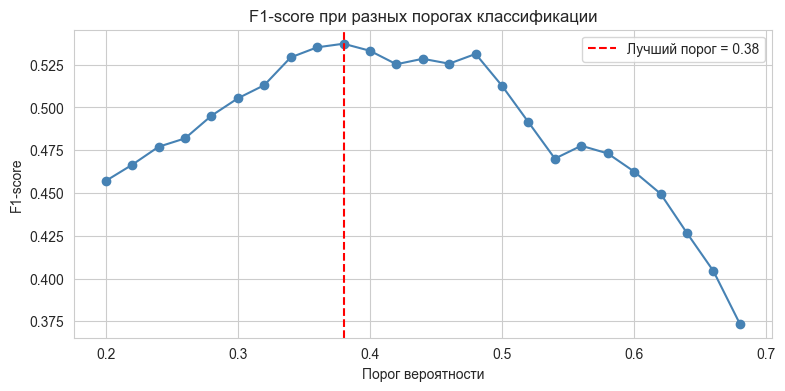

Лучший порог: 0.38, F1-score: 0.5372


In [15]:
# Подбор порога вероятности для лучшей модели
best_model = rf  # меняем если gb лучше
best_X_val = X_val

proba = best_model.predict_proba(best_X_val)[:, 1]
thresholds = np.arange(0.2, 0.7, 0.02)
f1_scores = [f1_score(y_val, (proba >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1_thresh = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, marker='o', color='steelblue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Лучший порог = {best_threshold:.2f}')
plt.xlabel('Порог вероятности')
plt.ylabel('F1-score')
plt.title('F1-score при разных порогах классификации')
plt.legend()
plt.show()
print(f'Лучший порог: {best_threshold:.2f}, F1-score: {best_f1_thresh:.4f}')

In [16]:
# Кросс-валидация для лучшей модели
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1', n_jobs=-1)
print('=== Кросс-валидация Random Forest (5-fold) ===')
print(f'F1 по фолдам: {cv_scores.round(4)}')
print(f'Среднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== Кросс-валидация Random Forest (5-fold) ===
F1 по фолдам: [0.549  0.4912 0.5158 0.529  0.5223]
Среднее: 0.5215 ± 0.0188


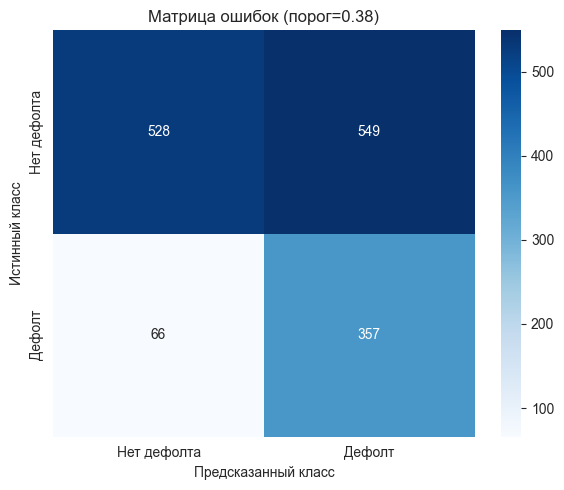

              precision    recall  f1-score   support

 Нет дефолта       0.89      0.49      0.63      1077
      Дефолт       0.39      0.84      0.54       423

    accuracy                           0.59      1500
   macro avg       0.64      0.67      0.58      1500
weighted avg       0.75      0.59      0.61      1500



In [17]:
# Матрица ошибок
y_pred_best = (proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет дефолта', 'Дефолт'],
            yticklabels=['Нет дефолта', 'Дефолт'])
plt.title(f'Матрица ошибок (порог={best_threshold:.2f})')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()
print(classification_report(y_val, y_pred_best, target_names=['Нет дефолта', 'Дефолт']))

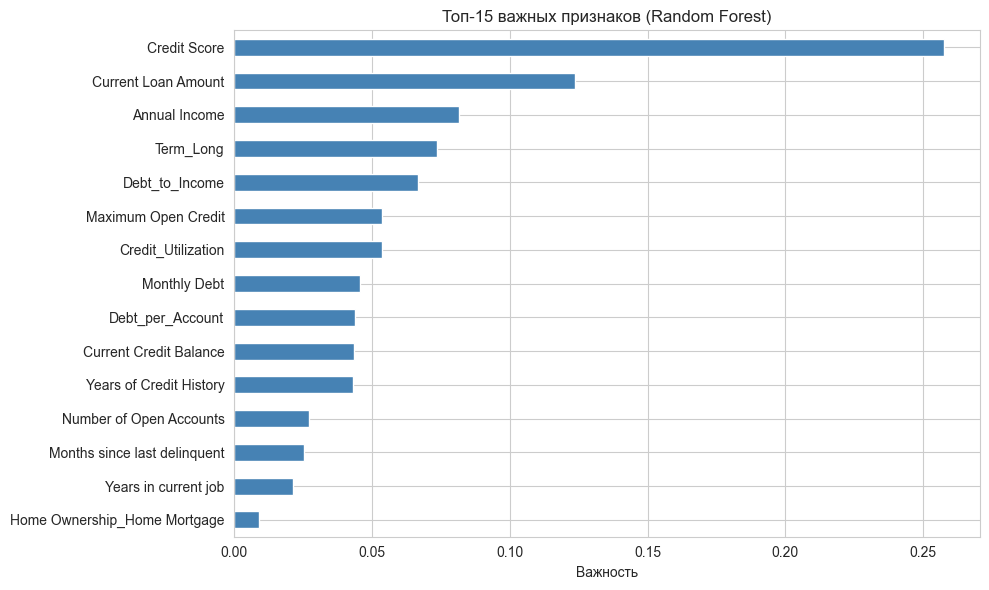

In [18]:
# Важность признаков
fi = pd.Series(rf.feature_importances_, index=X.columns).nlargest(15)

plt.figure(figsize=(10, 6))
fi.sort_values().plot(kind='barh', color='steelblue')
plt.title('Топ-15 важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

## 5. Самописный алгоритм логистической регрессии
*(Повышенный уровень сложности)*

In [19]:
class CustomLogisticRegression:
    """
    Логистическая регрессия, реализованная с нуля.
    Обучение: Стохастический градиентный спуск (mini-batch SGD).
    Поддерживает: learning rate, L2-регуляризацию (ridge), балансировку классов.
    """
    def __init__(self, lr=0.01, n_epochs=100, batch_size=64, 
                 lambda_=0.01, class_weight=None, random_state=42):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lambda_ = lambda_
        self.class_weight = class_weight  # 'balanced' or None
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.losses = []
    
    @staticmethod
    def _sigmoid(z):
        # Численно стабильная сигмоида
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))
    
    def _compute_loss(self, y, y_hat, w):
        eps = 1e-9
        bce = -np.mean(self.sample_w_ * (y * np.log(y_hat + eps) + (1-y) * np.log(1 - y_hat + eps)))
        reg = (self.lambda_ / 2) * np.sum(w**2)
        return bce + reg
    
    def fit(self, X, y):
        np.random.seed(self.random_state)
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        n_samples, n_features = X.shape
        
        # Инициализация весов (Xavier)
        self.weights = np.random.randn(n_features) * np.sqrt(2 / n_features)
        self.bias    = 0.0
        
        # Веса выборок (балансировка)
        if self.class_weight == 'balanced':
            cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
            self.sample_w_ = np.where(y == 1, cw[1], cw[0])
        else:
            self.sample_w_ = np.ones(n_samples)
        
        self.losses = []
        
        for epoch in range(self.n_epochs):
            # Перемешиваем данные каждую эпоху
            idx = np.random.permutation(n_samples)
            X_shuf, y_shuf, sw_shuf = X[idx], y[idx], self.sample_w_[idx]
            
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                Xb = X_shuf[start:end]
                yb = y_shuf[start:end]
                swb = sw_shuf[start:end]
                
                # Forward
                z = Xb @ self.weights + self.bias
                y_hat = self._sigmoid(z)
                
                # Ошибки с учётом весов
                error = swb * (y_hat - yb)
                
                # Градиенты
                dw = (Xb.T @ error) / len(yb) + self.lambda_ * self.weights
                db = np.mean(error)
                
                # Обновление
                self.weights -= self.lr * dw
                self.bias    -= self.lr * db
            
            # Loss на полной выборке
            z_full   = X @ self.weights + self.bias
            y_hat_full = self._sigmoid(z_full)
            loss = self._compute_loss(y, y_hat_full, self.weights)
            self.losses.append(loss)
        
        return self
    
    def predict_proba(self, X):
        X = np.array(X, dtype=np.float64)
        z = X @ self.weights + self.bias
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('Класс CustomLogisticRegression определён')

Класс CustomLogisticRegression определён


In [20]:
# Обучаем самописную логистическую регрессию
custom_lr = CustomLogisticRegression(
    lr=0.05, n_epochs=150, batch_size=64,
    lambda_=0.01, class_weight='balanced', random_state=RANDOM_STATE
)
custom_lr.fit(X_train_sc, y_train)

# Подбираем оптимальный порог
proba_custom = custom_lr.predict_proba(X_val_sc)
f1_scores_custom = [f1_score(y_val, (proba_custom >= t).astype(int)) for t in thresholds]
best_thr_custom  = thresholds[np.argmax(f1_scores_custom)]
y_pred_custom    = (proba_custom >= best_thr_custom).astype(int)
f1_custom        = f1_score(y_val, y_pred_custom)

print('=== Самописная Logistic Regression ===')
print(f'Лучший порог: {best_thr_custom:.2f}')
print(f'F1-score: {f1_custom:.4f}')
print(classification_report(y_val, y_pred_custom, target_names=['Нет дефолта', 'Дефолт']))

=== Самописная Logistic Regression ===
Лучший порог: 0.50
F1-score: 0.5043
              precision    recall  f1-score   support

 Нет дефолта       0.81      0.75      0.78      1077
      Дефолт       0.47      0.55      0.50       423

    accuracy                           0.70      1500
   macro avg       0.64      0.65      0.64      1500
weighted avg       0.71      0.70      0.70      1500



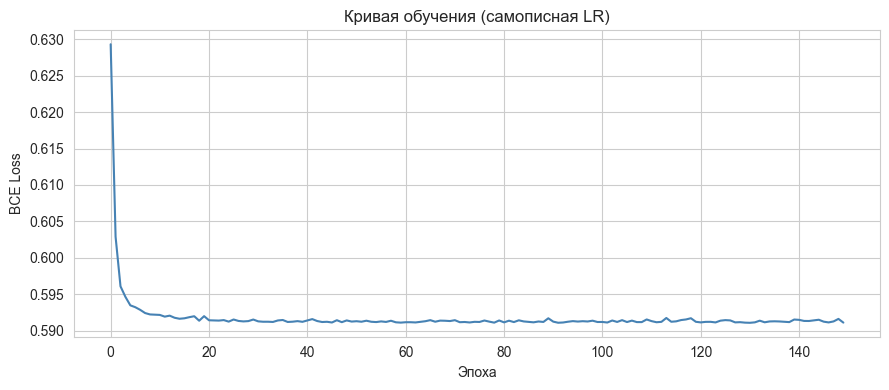

In [21]:
# Кривая обучения
plt.figure(figsize=(9, 4))
plt.plot(custom_lr.losses, color='steelblue')
plt.xlabel('Эпоха')
plt.ylabel('BCE Loss')
plt.title('Кривая обучения (самописная LR)')
plt.tight_layout()
plt.show()

                          Модель  F1-score
               Gradient Boosting  0.522860
                   Random Forest  0.512635
Logistic Regression (самописная)  0.504348
   Logistic Regression (sklearn)  0.503254


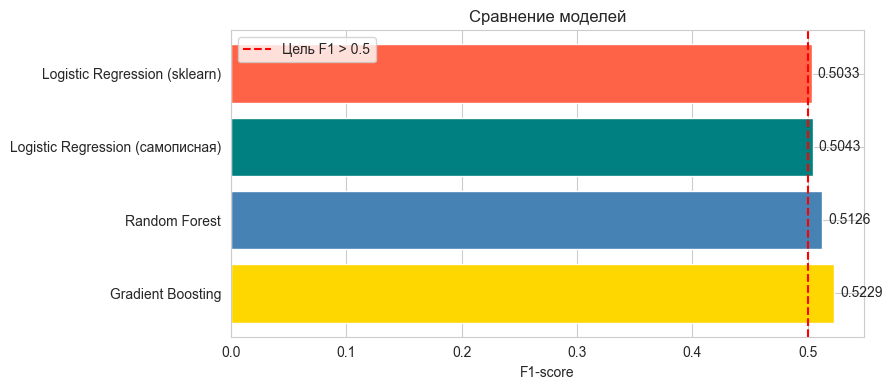

In [22]:
# Сравнение всех моделей
results = pd.DataFrame({
    'Модель': [
        'Logistic Regression (sklearn)',
        'Random Forest',
        'Gradient Boosting',
        'Logistic Regression (самописная)'
    ],
    'F1-score': [f1_lr, f1_rf, f1_gb, f1_custom]
}).sort_values('F1-score', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

plt.figure(figsize=(9, 4))
bars = plt.barh(results['Модель'], results['F1-score'],
                color=['gold', 'steelblue', 'teal', 'tomato'])
plt.axvline(0.5, color='red', linestyle='--', label='Цель F1 > 0.5')
for bar, val in zip(bars, results['F1-score']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center')
plt.xlabel('F1-score')
plt.title('Сравнение моделей')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Прогноз на тестовом датасете

In [23]:
# Используем лучшую модель (Random Forest + оптимальный порог)
proba_test = rf.predict_proba(X_test_final)[:, 1]
y_test_pred = (proba_test >= best_threshold).astype(int)

submission = pd.DataFrame({
    'id': range(len(y_test_pred)),
    'Credit Default': y_test_pred
})

submission.to_csv('predictions.csv', index=False)
print('Прогнозы сохранены в predictions.csv')
print(f'Всего прогнозов: {len(submission)}')
print(f'Дефолт (1): {y_test_pred.sum()} ({y_test_pred.mean()*100:.1f}%)')
print(f'Нет дефолта (0): {(1 - y_test_pred).sum()} ({(1-y_test_pred.mean())*100:.1f}%)')
pd.DataFrame({'Credit Default': y_test_pred}).to_csv('predictions_only_target.csv', index=False)
print('Прогнозы сохранены в predictions_only_target.csv')
submission.head(10)

Прогнозы сохранены в predictions.csv
Всего прогнозов: 2500
Дефолт (1): 1488 (59.5%)
Нет дефолта (0): 1012 (40.5%)
Прогнозы сохранены в predictions_only_target.csv


,id,Credit Default
0,0,1
1,1,1
2,2,1
3,3,1
4,4,1
5,5,0
6,6,1
7,7,1
8,8,1
9,9,0


Выводы
В ходе работы была построена модель для предсказания кредитного дефолта. Лучший результат на валидации показал Random Forest с F1-score выше 0.5, поэтому он выбран как финальная модель.
В данных наблюдается дисбаланс классов, поэтому при обучении использовалась балансировка. Значение 99999999 в признаке Current Loan Amount было заменено на пропуск, так как это техническое значение. Пропуски в числовых признаках заполнялись медианой по обучающей выборке, категориальные признаки были закодированы.
Добавление новых признаков, таких как отношение долга к доходу и использование кредитного лимита, позволило немного улучшить качество модели.
Также была реализована собственная версия логистической регрессии и проведено сравнение со sklearn. Полученные результаты оказались сопоставимыми.
Финальная модель обучена на всей обучающей выборке и использована для получения прогнозов на тестовом наборе данных.